#1) Importing libraries

In [26]:
import numpy as np
import pandas as pd
import csv
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing ,metrics ,datasets,model_selection
from sklearn import linear_model,svm,ensemble,tree
from sklearn.feature_selection import chi2 ,SelectKBest,f_classif
from xgboost import XGBRegressor
import tensorflow as tf

In [27]:
data=pd.read_csv("/content/surat_uncleaned.csv")
data.head(10)
df=data.copy()


#2) Data processing

##1)Removing the useless columns

In [28]:
df.drop(["description"],axis=1,inplace=True)
df.drop(["property_name"],axis=1,inplace=True)

##2)Handilng nulls

In [29]:
df["facing"]=df["facing"].fillna('East')
df.dropna(subset=["price_per_sqft"],inplace=True)
df["furnishing"]=df['furnishing'].fillna('Unfurnished')
df.dropna(inplace=True)

##3)Data cleaning

In [30]:
def convert_to_sqft(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower().replace(",", "")
    parts = x.split()
    if len(parts) == 1:
        try:
            return float(parts[0])
        except:
            return np.nan
    value = float(parts[0])
    unit = parts[1]
    if unit == "sqft":
        return value
    elif unit == "sqm":
        return value * 10.7639
    elif unit == "sqyrd":
        return value * 9
    else:
        return np.nan

df["square_feet"] = df["square_feet"].apply(convert_to_sqft)

In [31]:
df = df[df['transaction'].isin(['Resale','New Property','Unfurnished','Semi-Furnished'])]
df.loc[df['status'] != 'Ready to Move', 'status'] = 'Not Ready'
df = df[df['facing'].isin(['East','South -West','North - East'])]
df.loc[~df['furnishing'].isin(['Unfurnished', 'Furnished', 'Semi-Furnished']),'furnishing'] = 'Unfurnished'

In [32]:
df['floor']=df['floor'].str.replace('Ground','1')
df['floor']=df['floor'].str.replace('Lower Basement','-1')
df = df[~df["floor"].str.contains("Upper Basement|Resale|New Property",case=False,na=False)]

In [33]:
df['price_per_sqft'] = (df['price_per_sqft'] .str.strip() .str.replace(',', '', regex=False).str.extract(r'(\d+\.?\d*)')[0].astype(float))
df=df[~df['price'].str.contains('Call for Price')]
lac_price=df['price'][df['price'].str.contains('Lac')]
cr_price=df['price'][df['price'].str.contains('Cr')]
lac_price=lac_price.str.strip().str.extract(r'(\d+\.?\d*)')[0].astype(float)
cr_price=cr_price.str.strip().str.extract(r'(\d+\.?\d*)')[0].astype(float)
cr_price=cr_price.apply(lambda x:x*100)
df['price']=pd.concat([lac_price,cr_price])

##4)Encoding

In [34]:
#One Hot Encoding
df=pd.get_dummies(df,columns=['areaWithType'],dtype=int)
df=pd.get_dummies(data= df,columns=['transaction'],dtype=int)
df=pd.get_dummies(data=df,columns=['facing'],dtype=int)

#Label Encoding
df['status']=df['status'].replace({"Ready to Move":0,"Not Ready":1})
df['furnishing']=df['furnishing'].replace({'Unfurnished':0, 'Furnished':2, 'Semi-Furnished':1})

/tmp/ipykernel_1485/2227867938.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['status']=df['status'].replace({"Ready to Move":0,"Not Ready":1})
/tmp/ipykernel_1485/2227867938.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['furnishing']=df['furnishing'].replace({'Unfurnished':0, 'Furnished':2, 'Semi-Furnished':1})


In [35]:
df=df.reset_index()
df.drop(columns='index',inplace=True)


#3) Data Visualization

<Axes: >

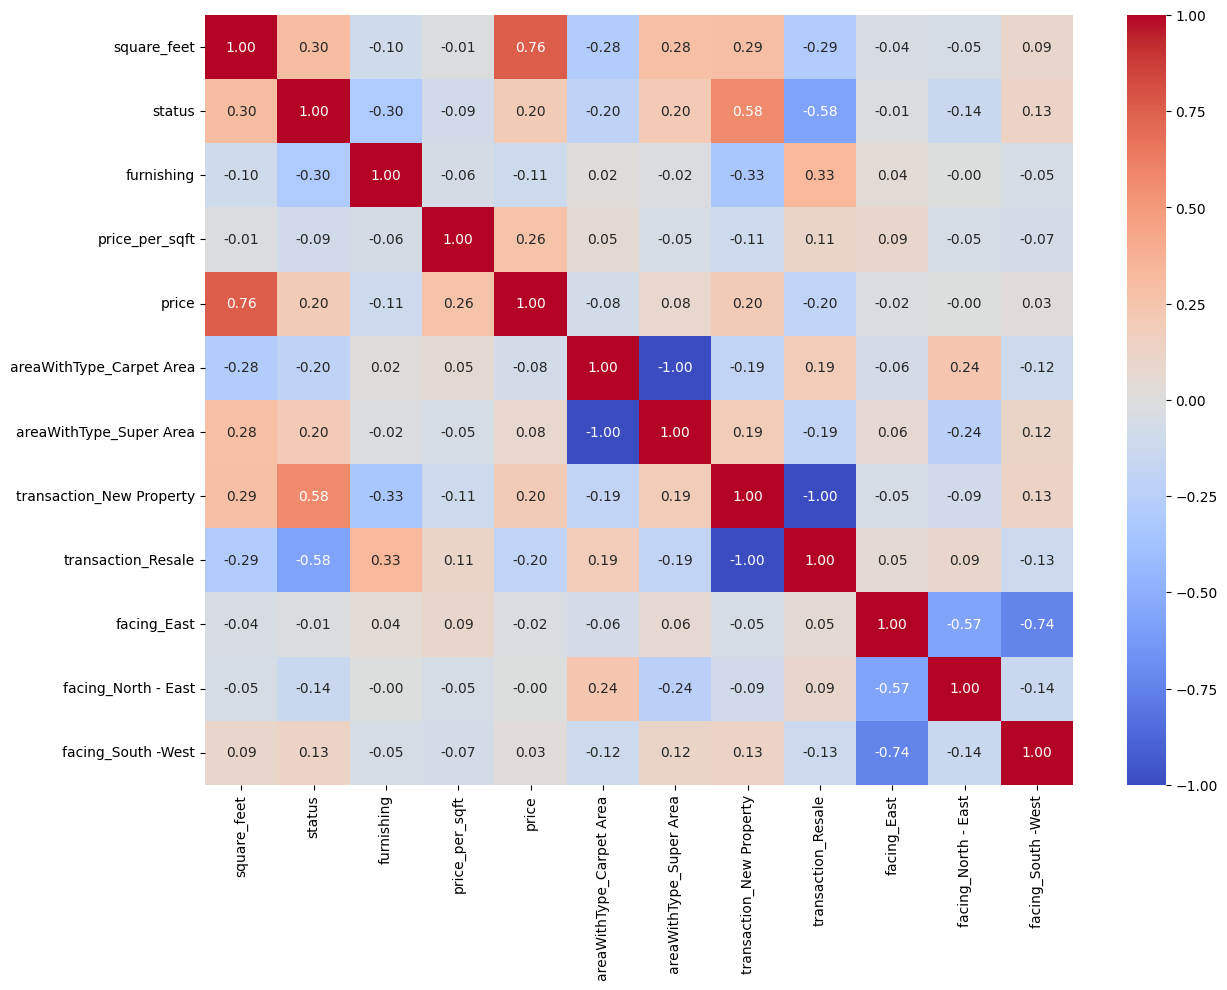

In [36]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")

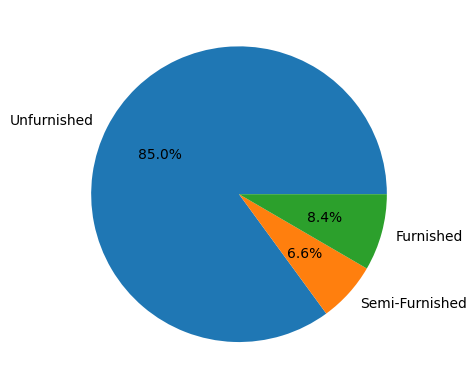

In [46]:
counts = df['furnishing'].value_counts().sort_index()
labels = {0: "Unfurnished",1: "Semi-Furnished",2: "Furnished"}
plt.pie(counts.values,labels=[labels[i] for i in counts.index],autopct='%1.1f%%')
plt.show()

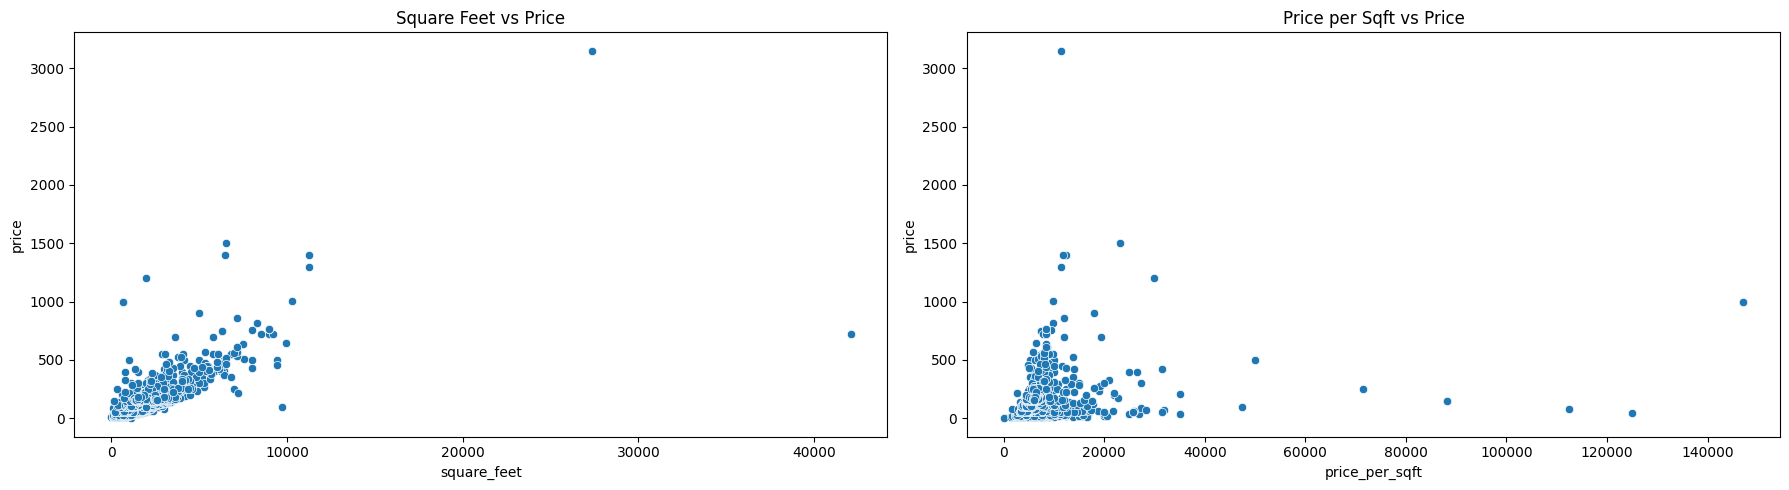

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

sns.scatterplot(data=df, x="square_feet", y="price", ax=axes[0])
axes[0].set_title("Square Feet vs Price")

sns.scatterplot(data=df, x="price_per_sqft", y="price", ax=axes[1])
axes[1].set_title("Price per Sqft vs Price")

plt.tight_layout()
plt.show()

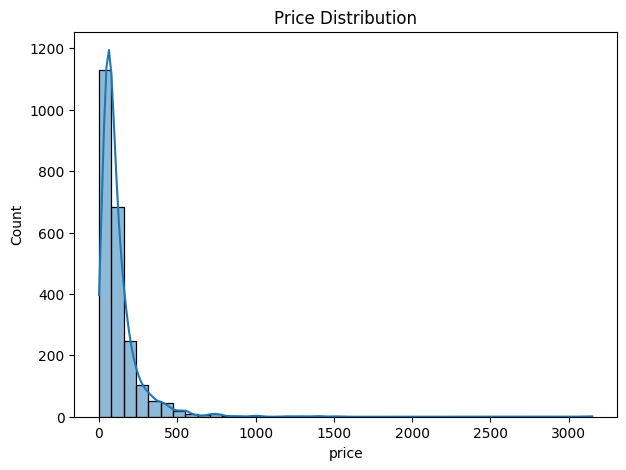

In [38]:
plt.figure(figsize=(7,5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

#4)Feature Extraction

In [39]:
df[['current_floor', 'total_floors']] = (df['floor'].str.extract(r'(\d+)\s*out of\s*(\d+)').astype(float))
df["floor_ratio"]=df['current_floor']/df['total_floors']
df.drop(columns='floor',inplace= True)
df.dropna(inplace=True)

#5) Feature Selection

In [40]:
# Spliting data
x=df.drop(columns='price')
y=df['price']
# fixing target distrbution
y=np.log1p(y)

In [41]:
feature_selection=SelectKBest(score_func=f_classif,k=11)
new_features=feature_selection.fit_transform(x,y)

In [42]:
#Restore labels to Features
pd.DataFrame(new_features,columns=[i for i,j in zip(x.columns,feature_selection.get_support()) if j])

,square_feet,status,price_per_sqft,areaWithType_Super Area,transaction_New Property,transaction_Resale,facing_East,facing_North - East,facing_South -West,current_floor,total_floors
0,1278.0,1.0,3551.0,1.0,1.0,0.0,0.0,0.0,1.0,6.0,14.0
1,1173.0,0.0,3800.0,1.0,0.0,1.0,1.0,0.0,0.0,5.0,13.0
2,700.0,0.0,3966.0,0.0,1.0,0.0,1.0,0.0,0.0,6.0,14.0
3,700.0,1.0,3392.0,0.0,1.0,0.0,1.0,0.0,0.0,7.0,10.0
4,720.0,1.0,3200.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...
2309,7150.0,0.0,8503.0,1.0,1.0,0.0,1.0,0.0,0.0,11.0,12.0
2310,4000.0,0.0,8000.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,12.0
2311,3500.0,1.0,6500.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,12.0
2312,3000.0,1.0,6200.0,1.0,1.0,0.0,1.0,0.0,0.0,5.0,12.0


#6)Model Training

In [43]:
# Normalizaion
x_scal=preprocessing.StandardScaler()
x=x_scal.fit_transform(x)

y_scal=preprocessing.MinMaxScaler()
y=y_scal.fit_transform(y.values.reshape(-1, 1))

In [44]:
x_train,x_test,y_train,y_test=model_selection.train_test_split(x,y,test_size=0.25,random_state=42,shuffle=True)

# LinearRegression Algorithm
linear_Regression_Model=linear_model.LinearRegression()
# RandomForest Algorithm
Random_Forset_Model=ensemble.RandomForestRegressor(n_estimators=200,max_depth=20)
#DecisionTree Algorithm
Decision_Tree_Model=tree.DecisionTreeRegressor(max_depth=20)
#SVM Algorithm
Svm_Model=svm.LinearSVR(max_iter=10000)
# XGBoost
XGboost_Model=XGBRegressor(n_estimators=200,max_depth=4,learning_rate=0.05,
                          subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric='logloss')
# Neural Networks
Neural_network_Model=keras.models.Sequential([
    keras.layers.Dense(8,activation='relu'),
    keras.layers.Dense(32,activation='linear'),
    keras.layers.Dense(128,activation='relu'),
    #keras.layers.Dropout(0.3),
    keras.layers.Dense(64,activation='linear'),
    keras.layers.Dense(1)
])

Neural_network_Model.compile(optimizer='adam',loss='mse',metrics=['mse'])



#7)Model Evalution

In [45]:
Models = {
    "Linear Regression": linear_Regression_Model,
    "Random Forest": Random_Forset_Model,
    "Decision Tree": Decision_Tree_Model,
    "SVM": Svm_Model,
    "XGBoost": XGboost_Model,
    }

Models_score = {}

for name, model in Models.items():
    model.fit(x_train, y_train)
    y_predict = model.predict(x_test)
    score = metrics.mean_absolute_error(y_test, y_predict)
    Models_score[name] = score

Neural_network_Model.fit(x_train,y_train,validation_data=(x_test,y_test),
                        epochs=20,batch_size=64,callbacks=[
                        tf.keras.callbacks.EarlyStopping(
                        patience=10,monitor='val_loss',restore_best_weights=True)])

y_pred=Neural_network_Model.predict(x_test)
neural_score=metrics.mean_absolute_error(y_test,y_pred)

for name, score in Models_score.items():
    print(f"{name} : {score}")

print(f"Neuralnetwork :{neural_score}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0538 - mse: 0.0538 - val_loss: 0.0154 - val_mse: 0.0154
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0124 - mse: 0.0124 - val_loss: 0.0087 - val_mse: 0.0087
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 - mse: 0.0075 - val_loss: 0.0092 - val_mse: 0.0092
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 - mse: 0.0067 - val_loss: 0.0102 - val_mse: 0.0102
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065 - mse: 0.0065 - val_loss: 0.0104 - val_mse: 0.0104
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062 - mse: 0.0062 - val_loss: 0.0095 - val_mse: 0.0095
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0096 - val_mse: 0.0096
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0075 - mse: 0.0075 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0057 - mse: 